# Zomato Restaurant Data Exploratory Data Analysis

## Project Overview

This project performs Exploratory Data Analysis (EDA) on the Zomato Restaurant Dataset to understand restaurant characteristics, customer ratings, pricing patterns, cuisines, geographical distribution, and online delivery trends.

The objective is to identify meaningful business insights through descriptive statistics, visualization, and data exploration before any predictive modeling.

### Objectives

- Understand the structure of the dataset
- Identify missing values
- Explore numerical and categorical variables
- Merge restaurant information with country information
- Analyze restaurant ratings
- Study country-wise restaurant distribution
- Explore online delivery and currency usage
- Identify popular cuisines and cities

## Import Required Libraries

The following libraries are imported for data manipulation, statistical analysis, and visualization throughout the exploratory analysis.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Dataset

The Zomato restaurant dataset is loaded into a Pandas DataFrame for further exploration and analysis.

In [5]:
df=pd.read_csv('zomato.csv',encoding='latin1')
df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,ÛÁstanbul,"CafeaÛôa Mahallesi, BademaltÛ± Sokak, No 21/B,...",Moda,"Moda, ÛÁstanbul",29.026016,40.984776,Cafe,...,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


## Initial Data Exploration

The first step is to inspect the dataset by examining:

- Dataset dimensions
- Column names
- Data types
- Summary statistics
- Overall structure

This helps understand the available features before performing detailed analysis.

In [6]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [10]:
df.drop('Restaurant ID', axis=1).describe()

,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


# Exploratory Data Analysis

The exploratory analysis consists of the following major steps:

- Handling missing values
- Understanding numerical variables
- Understanding categorical variables
- Merging external country information
- Rating analysis
- Country-wise analysis
- Currency analysis
- Online delivery analysis
- City distribution
- Cuisine popularity analysis

In [12]:
df.shape

(9551, 21)

The dataset has 9551 columns and 21 rows

## Missing Value Analysis

Missing values are identified to determine data quality and understand whether preprocessing is required before analysis.

In [13]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [16]:
null_columns=[col for col in df.columns if df[col].isnull().sum()>0]
null_columns

['Cuisines']

## Country Information Integration

The restaurant dataset contains only country codes.

An external lookup table is loaded and merged with the main dataset to replace country codes with readable country names, making the analysis easier to interpret.

In [20]:
df_country=pd.read_excel('Country-Code.xlsx')
df_country.head(8)

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia
5,148,New Zealand
6,162,Phillipines
7,166,Qatar


In [22]:
final_df=pd.merge(df, df_country, on='Country Code', how='left')
final_df.tail(3)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,No,No,No,No,4,3.7,Yellow,Good,661,Turkey
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,No,No,No,No,4,4.0,Green,Very Good,901,Turkey
9550,5927402,Walter's Coffee Roastery,208,ÛÁstanbul,"CafeaÛôa Mahallesi, BademaltÛ± Sokak, No 21/B,...",Moda,"Moda, ÛÁstanbul",29.026016,40.984776,Cafe,...,No,No,No,No,2,4.0,Green,Very Good,591,Turkey


In [23]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [24]:
final_df.dtypes

Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
Country                  object
dtype: object

In [28]:
final_df['Country'].value_counts()

Country
India             8652
United States      434
United Kingdom      80
Brazil              60
UAE                 60
South Africa        60
New Zealand         40
Turkey              34
Australia           24
Phillipines         22
Indonesia           21
Singapore           20
Qatar               20
Sri Lanka           20
Canada               4
Name: count, dtype: int64

## Country-wise Restaurant Distribution

This visualization shows the geographical distribution of restaurants across different countries and highlights the countries with the largest representation in the dataset.

Text(0.5, 1.0, 'orders By Country')

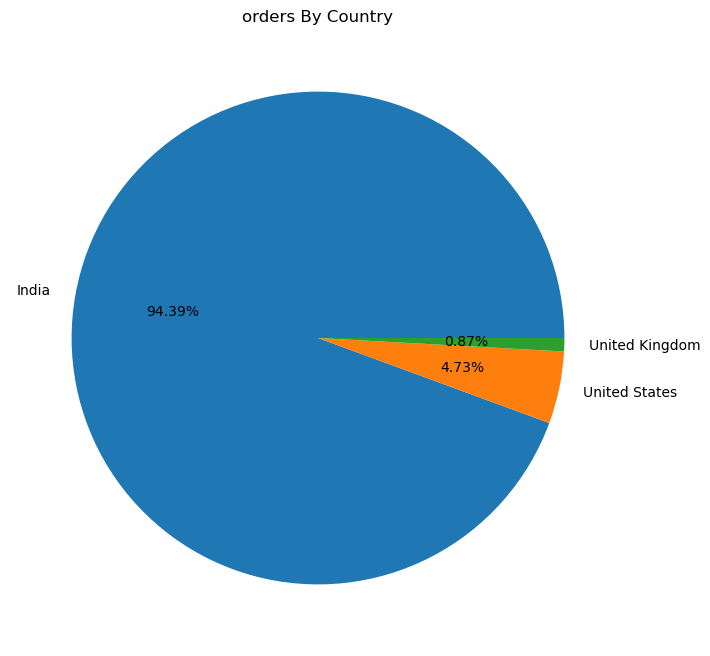

In [101]:
plt.figure(figsize=(10,8))
plt.pie(x=final_df['Country'].value_counts().values[:3], labels=final_df['Country'].value_counts().index[:3], autopct='%1.2f%%')
plt.title('orders By Country')

## Rating Distribution Analysis

Restaurant ratings are grouped according to their rating value, rating color, and rating description to understand customer satisfaction levels.

In [67]:
ratings=final_df.groupby(['Aggregate rating','Rating color','Rating text']).size().reset_index().rename(columns={0:'Rating Count'})
ratings

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15
5,2.2,Red,Poor,27
6,2.3,Red,Poor,47
7,2.4,Red,Poor,87
8,2.5,Orange,Average,110
9,2.6,Orange,Average,191


### Rating Categories

The dataset categorizes restaurant ratings into qualitative groups.

| Rating Range | Category |
|--------------|----------|
| 4.5 – 4.9 | Excellent |
| 4.0 – 4.4 | Very Good |
| 3.5 – 3.9 | Good |
| 2.5 – 3.4 | Average |
| 2.0 – 2.4 | Poor |
| 0.0 | Not Rated |

/var/folders/99/nqyz4s796bx09s6p71mvxd5h0000gn/T/ipykernel_45397/1092268.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Aggregate rating',y='Rating Count',data=ratings, palette='viridis')


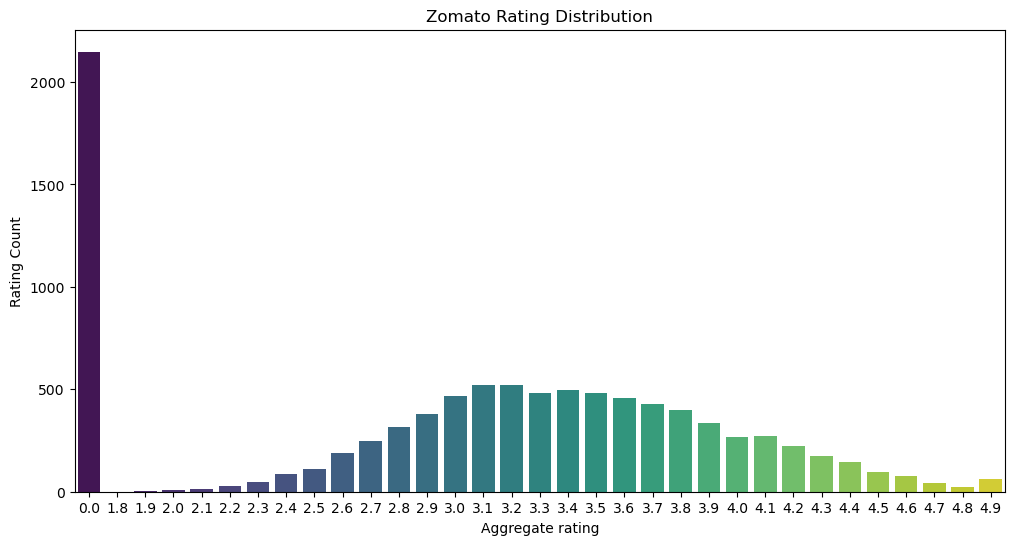

In [97]:
plt.figure(figsize=(12,6))
sns.barplot(x='Aggregate rating',y='Rating Count',data=ratings, palette='viridis')
plt.title('Zomato Rating Distribution')
plt.show()

## Rating Frequency Visualization

The rating distribution is visualized to understand how restaurants are distributed across different customer rating levels.

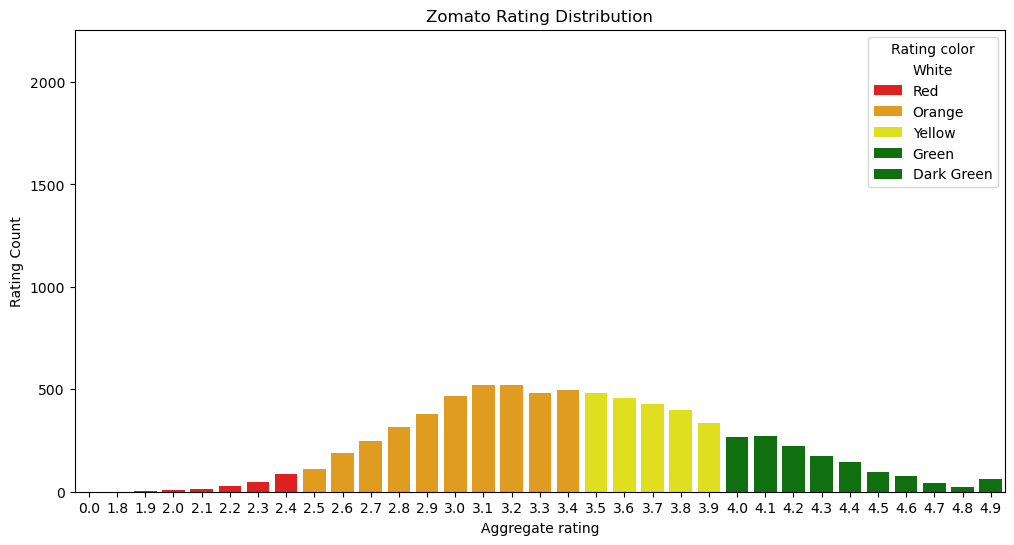

In [98]:
plt.figure(figsize=(12,6))
sns.barplot(x='Aggregate rating',y='Rating Count',data=ratings, hue='Rating color' ,palette=['white','red','orange','yellow','green','green'])
plt.title('Zomato Rating Distribution')
plt.show()

## Rating Color Distribution

Zomato associates each rating category with a color.

This visualization shows the frequency of each rating color across all restaurants.

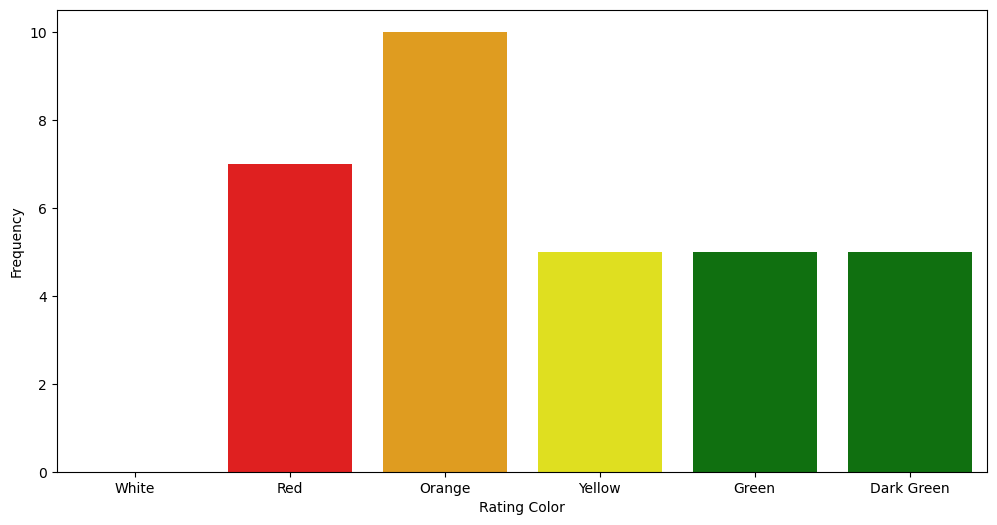

In [99]:
plt.figure(figsize=(12,6))
sns.countplot(data=ratings,x='Rating color',hue='Rating color',palette=['white','red','orange','yellow','green','green'])
plt.xlabel('Rating Color')
plt.ylabel('Frequency')
plt.show()

In [66]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [61]:
#Find the countries that has given 0 rating


In [69]:
final_df[final_df['Aggregate rating']==0].groupby('Country').size().reset_index().rename(columns={0:'Count'})

,Country,Count
0,Brazil,5
1,India,2139
2,United Kingdom,1
3,United States,3


In [70]:
#Find out which currency is used by which country

In [72]:
final_df[['Country','Currency']].drop_duplicates().sort_values('Country')

,Country,Currency
102,Australia,Dollar($)
22,Brazil,Brazilian Real(R$)
185,Canada,Dollar($)
624,India,Indian Rupees(Rs.)
9276,Indonesia,Indonesian Rupiah(IDR)
9297,New Zealand,NewZealand($)
0,Phillipines,Botswana Pula(P)
9417,Qatar,Qatari Rial(QR)
456,Singapore,Dollar($)
9437,South Africa,Rand(R)


In [74]:
#Find the currency used most
final_df.groupby(['Country','Currency']).size().reset_index().rename(columns={0:'Count Of Currency'}).sort_values('Count Of Currency',ascending=False)

,Country,Currency,Count Of Currency
3,India,Indian Rupees(Rs.),8652
14,United States,Dollar($),434
13,United Kingdom,Pounds(£),80
1,Brazil,Brazilian Real(R$),60
9,South Africa,Rand(R),60
12,UAE,Emirati Diram(AED),60
5,New Zealand,NewZealand($),40
11,Turkey,Turkish Lira(TL),34
0,Australia,Dollar($),24
6,Phillipines,Botswana Pula(P),22


In [75]:
# Which country has online delivery option 

In [81]:
final_df[final_df['Has Online delivery']=='Yes']['Country'].unique()

array(['UAE', 'India'], dtype=object)

In [82]:
# Finding records having online delivery or not by country 

In [84]:
final_df.groupby(['Country','Has Online delivery']).size().reset_index()

,Country,Has Online delivery,0
0,Australia,No,24
1,Brazil,No,60
2,Canada,No,4
3,India,No,6229
4,India,Yes,2423
5,Indonesia,No,21
6,New Zealand,No,40
7,Phillipines,No,22
8,Qatar,No,20
9,Singapore,No,20


In [85]:
#Create pie chart for cities distribution

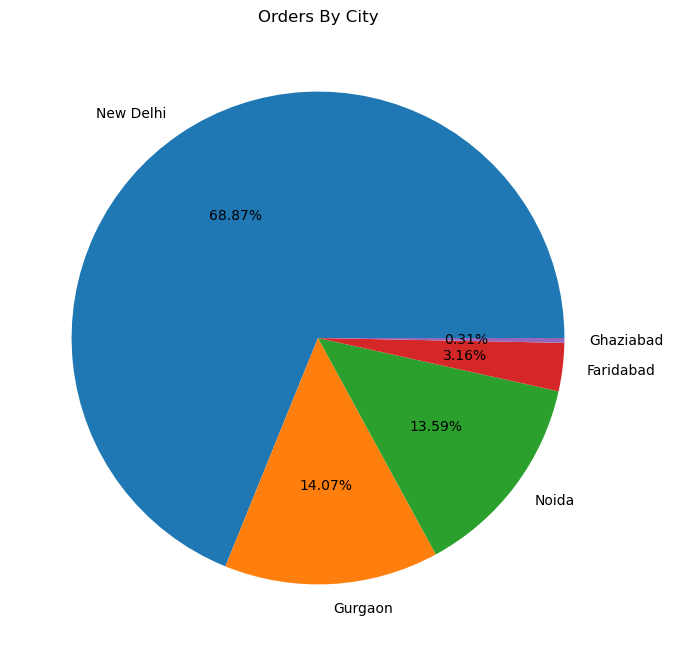

In [102]:
plt.figure(figsize=(10,8))
plt.pie(x=final_df['City'].value_counts().values[:5],labels=final_df['City'].value_counts().index[:5],autopct='%1.2f%%')
plt.title('Orders By City')
plt.show()

In [105]:
#Top 10 Cuisines

In [110]:
df.groupby('Cuisines').size().reset_index().rename(columns={0:'count'}).sort_values('count', ascending=False).head(10)

,Cuisines,count
1306,North Indian,936
1329,"North Indian, Chinese",511
497,Chinese,354
828,Fast Food,354
1514,"North Indian, Mughlai",334
331,Cafe,299
177,Bakery,218
1520,"North Indian, Mughlai, Chinese",197
186,"Bakery, Desserts",170
1749,Street Food,149
